In [1]:
import h5py
import numpy as np

# Open the file in read mode
with h5py.File('emnist_data.h5', 'r') as f:
    X_train = np.array(f['X_train'])
    y_train = np.array(f['y_train'])
    X_test  = np.array(f['X_test'])
    y_test  = np.array(f['y_test'])

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(697932, 28, 28) (697932,)
(116323, 28, 28) (116323,)


In [ ]:
import pickle

with open('emnist.pkl', 'rb') as f:
    (x_train, y_train), (x_test, y_test) = pickle.load(f)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)


In [ ]:
import tensorflow as tf
from tensorflow import keras

# Number of classes in EMNIST byclass (10 digits + 26 uppercase + 26 lowercase)
NUM_CLASSES = 62  

# Build the model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),          # Flatten 28x28 images to 784 vector
    keras.layers.Dense(256, activation="relu"),           # More neurons for complexity
    keras.layers.Dropout(0.3),                            # Regularization to avoid overfitting
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(NUM_CLASSES, activation="softmax") # Softmax for multi-class output
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Summary
model.summary()

model.fit(X_train, y_train, epochs=15, batch_size=64, validation_split=0.1)#epochs=7,

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
#16mins

c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,854 (944.74 KB)

 Trainable params: 241,854 (944.74 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
9815/9815 ━━━━━━━━━━━━━━━━━━━━ 64s 6ms/step - accuracy: 0.7376 - loss: 0.8598 - val_accuracy: 0.8161 - val_loss: 0.5395
Epoch 2/15
9815/9815 ━━━━━━━━━━━━━━━━━━━━ 70s 5ms/step - accuracy: 0.7824 - loss: 0.6722 - val_accuracy: 0.8234 - val_loss: 0.5101
Epoch 3/15
9815/9815 ━━━━━━━━━━━━━━━━━━━━ 62s 6ms/step - accuracy: 0.7906 - loss: 0.6424 - val_accuracy: 0.8269 - val_loss: 0.4935
Epoch 4/15
9815/9815 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - accuracy: 0.7951 - loss: 0.6256 - val_accuracy: 0.8310 - val_loss: 0.4812
Epoch 5/15
9815/9815 ━━━━━━━━━━━━━━━━━━━━ 50s 5ms/step - accuracy: 0.7977 - loss: 0.6157 - val_accuracy: 0.8327 - val_loss: 0.4789
Epoch 6/15
9815/9815 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - accuracy: 0.7996 - loss: 0.6092 - val_accuracy: 0.8339 - val_loss: 0.4764
Epoch 7/15
9815/9815 ━━━━━━━━━━━━━━━━━━━━ 88s 5ms/step - accuracy: 0.8002 - loss: 0.6047 - val_accuracy: 0.8356 - val_loss: 0.4700
Epoch 8/15
9815/9815 ━━━━━━━━━━━━━━━━━━━━ 49s 5ms/step - accuracy: 0.8021 - loss: 0

In [3]:
model.save('emnist_model83.keras')  # new format
# or model.save('emnist_model.h5')  # older format


3636/3636 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


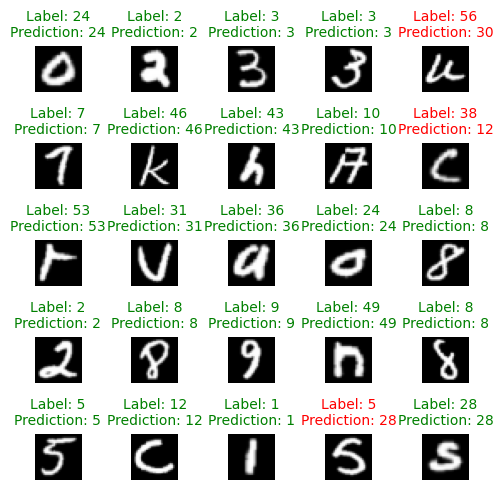

In [5]:
import matplotlib.pyplot as plt
predctions=model.predict(X_test)
predictions=[np.argmax(i) for i in predctions]
plt.figure(figsize=(5, 5))
for i in range(25):
 plt.subplot(5, 5, i + 1)
 plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
 plt.axis('off')
 plt.title(f'Label: {y_test[i]}\nPrediction: {predictions[i]}', color='green' if y_test[i] == predictions[i] else 'red', fontsize=10) # Adjusted fontsize
plt.tight_layout() # Added to prevent overlapping titles
plt.show()

In [7]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.66      0.84      0.74      5778
           1       0.63      0.97      0.77      6330
           2       0.92      0.97      0.94      5869
           3       0.97      0.98      0.97      5969
           4       0.94      0.96      0.95      5619
           5       0.93      0.86      0.89      5190
           6       0.95      0.96      0.96      5705
           7       0.97      0.99      0.98      6139
           8       0.96      0.95      0.95      5633
           9       0.89      0.97      0.93      5686
          10       0.90      0.91      0.90      1062
          11       0.84      0.82      0.83       648
          12       0.73      0.95      0.82      1739
          13       0.84      0.80      0.82       779
          14       0.95      0.86      0.90       851
          15       0.76      0.90      0.82      1440
          16       0.94      0.66      0.78       447
          17       0.85    

c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [ ]:
import tensorflow as tf
from tensorflow import keras

# Number of classes in EMNIST byclass
NUM_CLASSES = 62  # 10 digits + 26 uppercase + 26 lowercase

# Build CNN model
model = keras.Sequential([
    # --- Convolution + Pooling Layers ---
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Dropout(0.4),  # Regularization

    # --- Fully Connected Layers ---
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(NUM_CLASSES, activation='softmax')  # Final output layer
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()
# Example: Fit model with training data
# Assuming X_train, y_train, X_test, y_test are already preprocessed
# X should be shaped as (num_samples, 28, 28, 1)

model.fit(
    X_train, y_train,
    epochs=7,
    batch_size=128,
    validation_split=0.1
)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

#29mins

c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,774 (1.54 MB)

 Trainable params: 403,774 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/7
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 166s 33ms/step - accuracy: 0.8028 - loss: 0.6017 - val_accuracy: 0.8602 - val_loss: 0.3797
Epoch 2/7
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 171s 35ms/step - accuracy: 0.8445 - loss: 0.4388 - val_accuracy: 0.8645 - val_loss: 0.3615
Epoch 3/7
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 170s 35ms/step - accuracy: 0.8514 - loss: 0.4147 - val_accuracy: 0.8695 - val_loss: 0.3529
Epoch 4/7
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 331s 36ms/step - accuracy: 0.8547 - loss: 0.4022 - val_accuracy: 0.8701 - val_loss: 0.3488
Epoch 5/7
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 236s 48ms/step - accuracy: 0.8574 - loss: 0.3926 - val_accuracy: 0.8701 - val_loss: 0.3439
Epoch 6/7
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 302s 61ms/step - accuracy: 0.8594 - loss: 0.3857 - val_accuracy: 0.8721 - val_loss: 0.3401
Epoch 7/7
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 302s 61ms/step - accuracy: 0.8610 - loss: 0.3803 - val_accuracy: 0.8736 - val_loss: 0.3380
3636/3636 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.8721 - loss: 0.34

In [20]:
X_test.shape

(116323, 28, 28)

In [9]:
model.save('emnist_cnnmodel87.keras')

In [1]:
import keras
model = keras.models.load_model('emnist_cnnmodel87.keras')

In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0-dev20250925


In [3]:
print(keras.__version__)

3.12.0.dev2025093003


3636/3636 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step


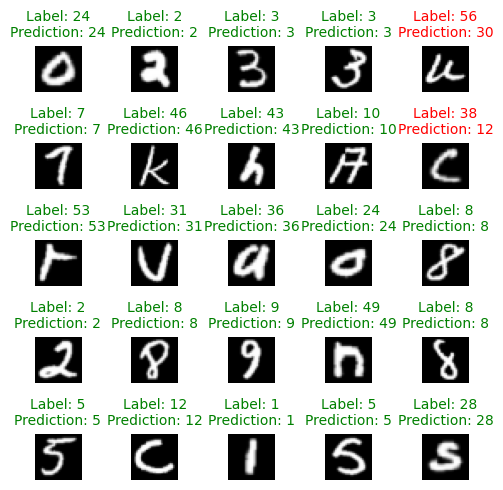

In [12]:
import matplotlib.pyplot as plt
predctions=model.predict(X_test)
predictions=[np.argmax(i) for i in predctions]
plt.figure(figsize=(5, 5))
for i in range(25):
 plt.subplot(5, 5, i + 1)
 plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
 plt.axis('off')
 plt.title(f'Label: {y_test[i]}\nPrediction: {predictions[i]}', color='green' if y_test[i] == predictions[i] else 'red', fontsize=10) # Adjusted fontsize
plt.tight_layout() # Added to prevent overlapping titles
plt.show()

In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.68      0.84      0.75      5778
           1       0.68      0.93      0.78      6330
           2       0.97      0.98      0.97      5869
           3       0.99      0.99      0.99      5969
           4       0.97      0.98      0.98      5619
           5       0.97      0.93      0.95      5190
           6       0.97      0.99      0.98      5705
           7       0.99      0.99      0.99      6139
           8       0.98      0.99      0.98      5633
           9       0.93      0.98      0.95      5686
          10       0.97      0.97      0.97      1062
          11       0.94      0.97      0.95       648
          12       0.78      0.94      0.85      1739
          13       0.94      0.90      0.92       779
          14       0.96      0.97      0.97       851
          15       0.78      0.97      0.86      1440
          16       0.95      0.87      0.91       447
          17       0.93    

c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [57]:
import cv2
input_image_path="two.webp"
input_image=cv2.imread(input_image_path)
gray_scale=cv2.cvtColor(input_image,cv2.COLOR_RGB2GRAY)
resized_image=cv2.resize(gray_scale,(28,28))

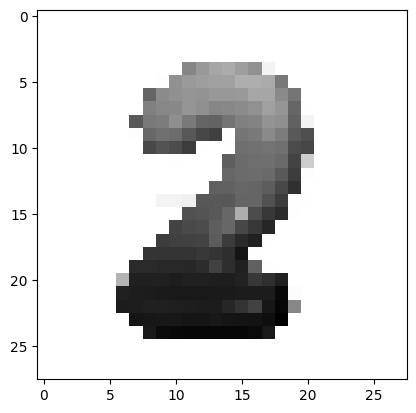

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(resized_image, cmap='gray')

In [ ]:
resized_image=abs(resized_image-255.0)
normalized_image=resized_image/255.0
input_image=normalized_image.reshape(1,28,28)
prediction=model.predict(input_image)
input_pred_label=np.argmax(prediction)
print(f"Predicted Label: {input_pred_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted Label: 2


In [62]:
import cv2
input_image_path="s_letter.jpg"
input_image=cv2.imread(input_image_path)
gray_scale=cv2.cvtColor(input_image,cv2.COLOR_RGB2GRAY)
resized_image=cv2.resize(gray_scale,(28,28))

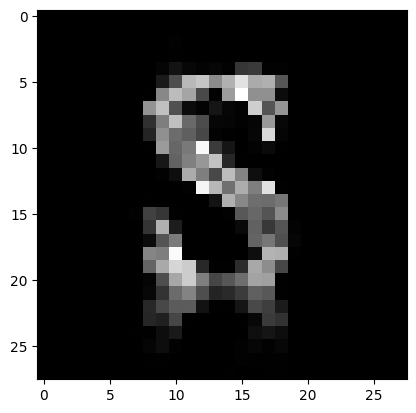

In [63]:
import matplotlib.pyplot as plt
plt.imshow(resized_image, cmap='gray')

In [64]:

normalized_image=resized_image/255.0
input_image=normalized_image.reshape(1,28,28)
prediction=model.predict(input_image)
input_pred_label=np.argmax(prediction)
print(f"Predicted Label: {input_pred_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted Label: 28
